# Exploratory Data Analysis (EDA)
## Introduction
This notebook presents the exploratory data analysis (EDA) of an online payment fraud detection dataset.

The goal of this analysis is to understand the characteristics of legitimate and fraudulent transactions, identify meaningful patterns in the data, and uncover insights that can support fraud detection. 

## Business Questions

This exploratory data analysis aims to answer the following questions:

1. How common are fraudulent transactions?
2. Which transaction types are most vulnerable to fraud?
3. Do fraudulent transactions involve larger transaction amounts than legitimate transactions?
4. How do account balances differ between fraudulent and legitimate transactions?
5. How are fraudulent transactions distributed over time?

## 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, and analysis throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Improve Chart Appearance

The default plotting style is customized to produce clear, consistent, and publication-quality visualizations throughout the analysis.


In [2]:
sns.set_style("whitegrid")

## 2. Load the Cleaned Dataset
The cleaned dataset generated is loaded from the processed data folder.

In [3]:
df = pd.read_csv("../data/processed/onlinefraud_cleaned.csv")

## 3. Verify the Dataset

Before beginning the analysis, the dataset is inspected to confirm that it has been loaded correctly and to understand its overall structure.

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.shape

(6362620, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


## 4. How Common Are Fraudulent Transactions?

Before investigating the characteristics of fraudulent transactions, it is important to understand how frequently fraud occurs in the dataset.

This analysis examines the distribution of legitimate and fraudulent transactions to determine the level of class imbalance.

### Transaction Counts

First, we count the number of legitimate and fraudulent transactions in the dataset.

In [7]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

### Transaction Percentages

Next, we calculate the percentage of legitimate and fraudulent transactions to better understand the degree of class imbalance.

In [8]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

### Fraud Distribution

A bar chart is used to compare the number of legitimate and fraudulent transactions. This visualization provides a clear picture of the imbalance between the two classes.

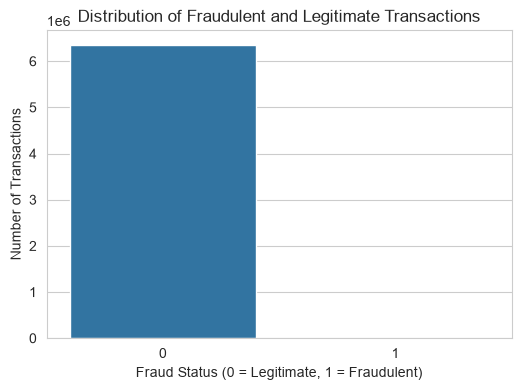

In [17]:
fraud_counts = df["isFraud"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Number of Transactions")

plt.savefig(
    "../images/1. fraud_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Findings

Fraudulent transactions account for approximately **0.13%** of all transactions, while legitimate transactions make up about **99.87%** of the dataset.

This indicates a highly imbalanced dataset, where fraudulent transactions are extremely rare compared to legitimate ones. 

### Business Insight

Since fraudulent transactions represent only a very small proportion of all transactions, an effective fraud detection system must accurately identify rare fraudulent events while minimizing false alarms on legitimate transactions.

## 5. Which Transaction Types Are Most Vulnerable to Fraud?

This analysis explores the distribution of transaction types and identifies which types are most frequently associated with fraudulent activity.

### Transaction Type Distribution

First, we examine the frequency of each transaction type in the dataset.

In [10]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

### Transaction Type Distribution Chart

A count plot is used to compare the number of transactions across each transaction type.

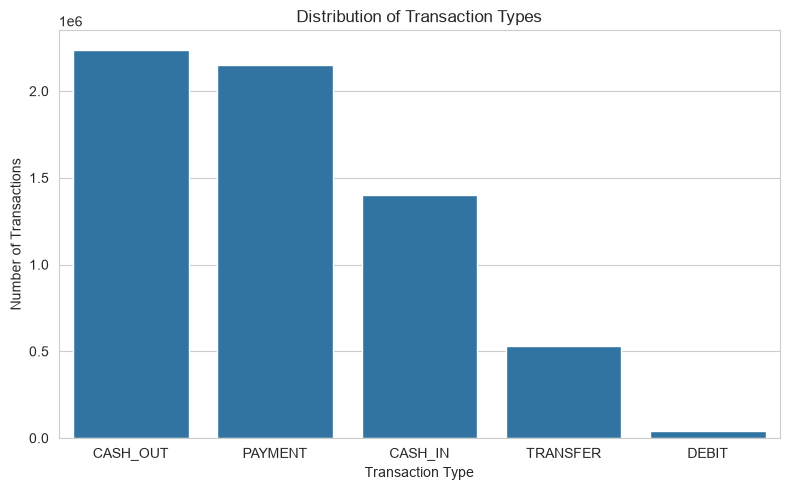

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.savefig(
    "../images/2. transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Findings

CASH_OUT is the most common transaction type in the dataset, while DEBIT transactions occur least frequently.

### Fraud by Transaction Type

Next, we compare legitimate and fraudulent transactions across each transaction type.


In [12]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

fraud_by_type

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


### Fraud Rate by Transaction Type

The fraud rate shows the percentage of transactions that are fraudulent within each transaction type.

In [13]:
fraud_rate = (
    df.groupby("type")["isFraud"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

fraud_rate

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

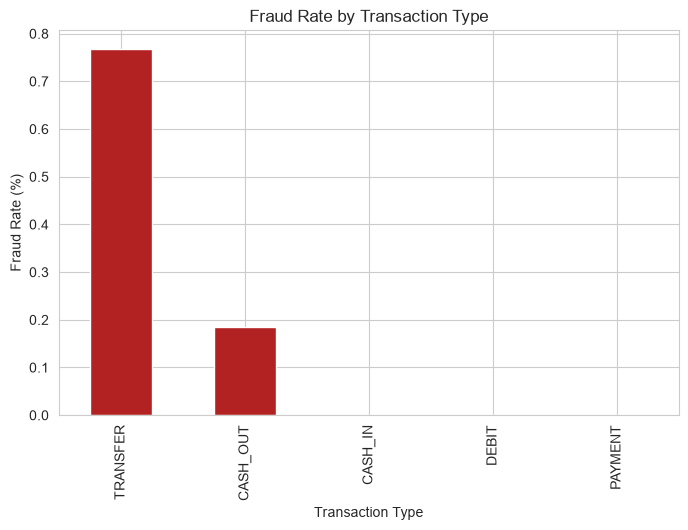

In [21]:
plt.figure(figsize=(8,5))

fraud_rate.plot(kind="bar", color="firebrick")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.savefig(
    "../images/3. fraud_ratetransaction_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Findings

Fraud occurs only in **TRANSFER** and **CASH_OUT** transactions. Although **CASH_OUT** contains slightly more fraudulent transactions, **TRANSFER** has the highest fraud rate, making it the riskiest transaction type in the dataset.

### Business Insight

Monitoring efforts should focus primarily on **TRANSFER** and **CASH_OUT** transactions, as these are the only transaction types associated with fraud in this dataset.

## 6. Do Fraudulent Transactions Involve Larger Transaction Amounts?

This analysis compares transaction amounts between legitimate and fraudulent transactions to determine whether fraud is associated with higher-value transactions.

### Summary Statistics

First, we compare the distribution of transaction amounts for legitimate and fraudulent transactions.

In [20]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


### Findings

Fraudulent transactions generally involve much larger transaction amounts than legitimate transactions. This difference suggests that transaction amount may be an important feature for detecting fraudulent activity.

### Transaction Amount Distribution

A boxplot is used to compare the distribution of transaction amounts for legitimate and fraudulent transactions. A logarithmic scale is applied because transaction amounts span a very wide range.

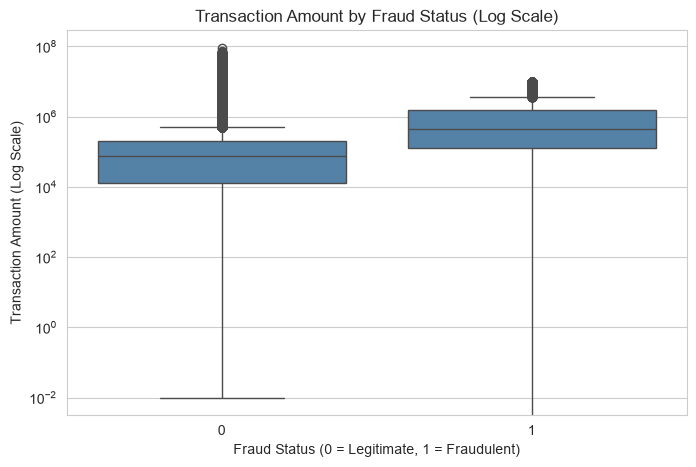

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount",
    color="steelblue"
)

plt.yscale("log")

plt.title("Transaction Amount by Fraud Status (Log Scale)")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Transaction Amount (Log Scale)")

plt.savefig(
    "../images/4. transaction_amount_by_fraud_status.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Findings

The boxplot shows that fraudulent transactions generally have higher median transaction amounts than legitimate transactions. Although both groups contain extreme outliers, transaction amount alone is not sufficient to distinguish fraud, indicating that additional transaction characteristics should also be considered.

### Business Insight

Higher-value transactions may deserve additional monitoring, particularly when combined with other suspicious transaction characteristics.

## 7. How Do Account Balances Differ Between Fraudulent and Legitimate Transactions?

This analysis compares account balances before and after transactions to determine whether fraudulent transactions exhibit different balance patterns.

### Sender Account Balance Summary

First, we compare the sender's account balances before and after transactions for legitimate and fraudulent transactions.

In [23]:
df.groupby("isFraud")[["oldbalanceOrg", "newbalanceOrig"]].describe()

oldbalanceOrg                                                         \
                count          mean           std  min        25%        50%   
isFraud                                                                        
0           6354407.0  8.328287e+05  2.887144e+06  0.0       0.00   14069.00   
1              8213.0  1.649668e+06  3.547719e+06  0.0  125822.44  438983.45   

                                 newbalanceOrig                               \
                75%          max          count           mean           std   
isFraud                                                                        
0         106969.50  43818855.30      6354407.0  855970.228109  2.924987e+06   
1        1517771.48  59585040.37         8213.0  192392.631836  1.965666e+06   

                                                
         min  25%  50%        75%          max  
isFraud                                         
0        0.0  0.0  0.0  144730.74  43686616.33  
1        0.0  0.0  0.0       0.00  49585040.37

In [24]:
df.groupby("isFraud")[["oldbalanceOrg", "newbalanceOrig"]].median()

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,14069.00,0.0
1,438983.45,0.0


The median is used because account balances contain extreme values that can significantly affect the mean.

### Sender Balance Before Transaction

This boxplot compares sender account balances before legitimate and fraudulent transactions.

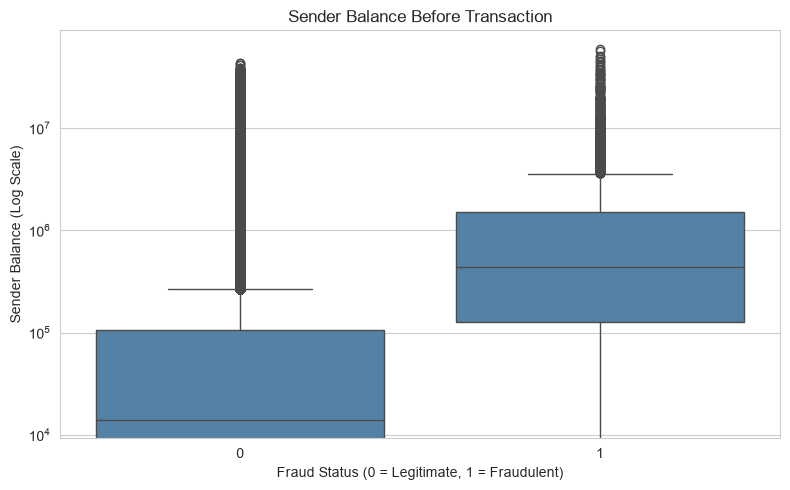

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="oldbalanceOrg",
    color="steelblue"
)

plt.yscale("log")

plt.title("Sender Balance Before Transaction")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Sender Balance (Log Scale)")

plt.tight_layout()

plt.savefig(
    "../images/5. sender_balance_before.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Sender Balance After Transaction

This boxplot compares sender account balances after legitimate and fraudulent transactions.

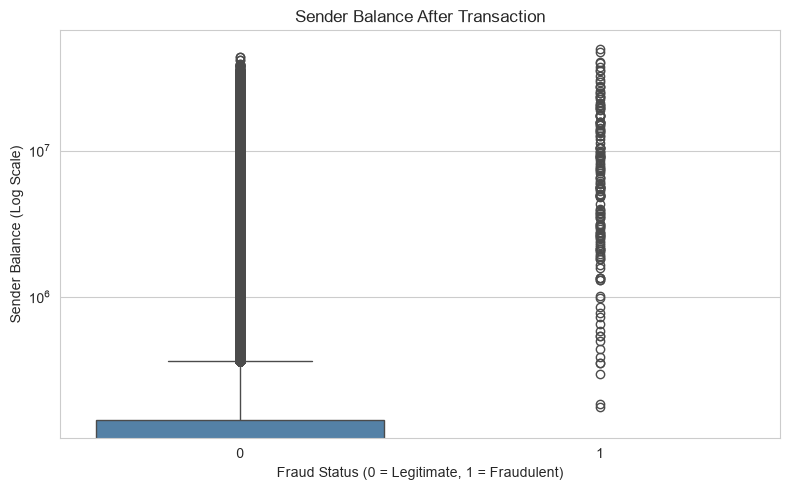

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="newbalanceOrig",
    color="steelblue"
)

plt.yscale("log")

plt.title("Sender Balance After Transaction")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Sender Balance (Log Scale)")

plt.savefig(
    "../images/6. sender_balance_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

### Findings

Fraudulent transactions generally originate from accounts with higher balances before the transaction than legitimate transactions.

After fraudulent transactions, sender account balances typically decrease substantially, with many fraudulent transactions leaving the sender's account close to zero. This suggests that fraud often involves transferring large amounts from funded accounts.

### Summary Statistics

First, we compare the recipient account balances for legitimate and fraudulent transactions.

In [27]:
df.groupby("isFraud")[["oldbalanceDest", "newbalanceDest"]].describe()

oldbalanceDest                                                  \
                 count          mean           std  min  25%       50%   
isFraud                                                                  
0            6354407.0  1.101421e+06  3.399202e+06  0.0  0.0  133311.8   
1               8213.0  5.442496e+05  3.336421e+06  0.0  0.0       0.0   

                                 newbalanceDest                              \
               75%           max          count          mean           std   
isFraud                                                                       
0        944144.58  3.560159e+08      6354407.0  1.224926e+06  3.673816e+06   
1        147828.66  2.362305e+08         8213.0  1.279708e+06  3.908817e+06   

                                                         
         min  25%        50%          75%           max  
isFraud                                                  
0        0.0  0.0  214881.70  1111975.345  3.561793e+08  
1        0.0  0.0    4676.42  1058725.220  2.367265e+08

### Median Recipient Balances

The median is used because account balances are highly skewed by a small number of very large values.

In [28]:
df.groupby("isFraud")[["oldbalanceDest", "newbalanceDest"]].median()

,oldbalanceDest,newbalanceDest
isFraud,,
0,133311.8,214881.70
1,0.0,4676.42


### Recipient Balance Before Transaction

The boxplot compares recipient account balances before transactions for legitimate and fraudulent transactions.

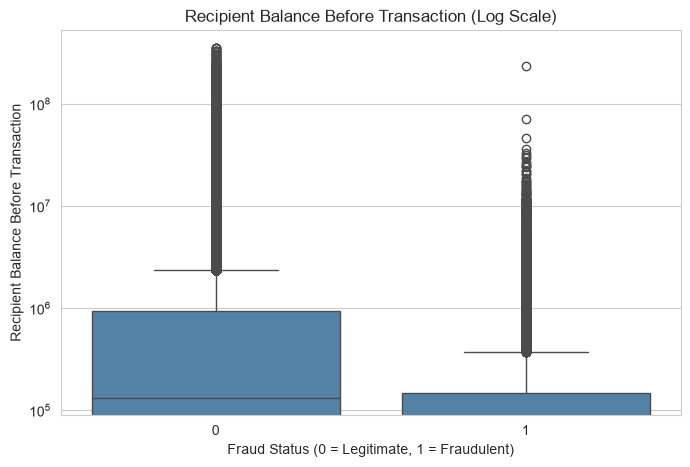

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="oldbalanceDest",
    color="steelblue"
)

plt.yscale("log")

plt.title("Recipient Balance Before Transaction (Log Scale)")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Recipient Balance Before Transaction")

plt.savefig(
    "../images/7. recipient_balance_before.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Recipient Balance After Transaction

This boxplot compares recipient account balances after transactions for legitimate and fraudulent transactions.

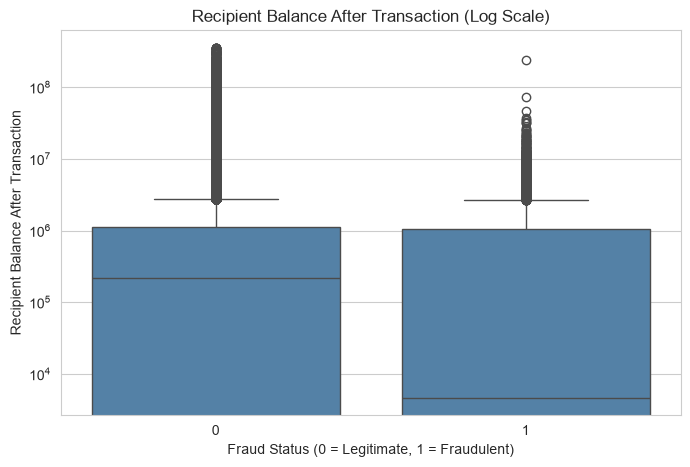

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="newbalanceDest",
    color="steelblue"
)

plt.yscale("log")

plt.title("Recipient Balance After Transaction (Log Scale)")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Recipient Balance After Transaction")

plt.savefig(
    "../images/8. recipient_balance_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Overall Findings

Both sender and recipient account balances show clear differences between legitimate and fraudulent transactions. Fraudulent transactions typically originate from well-funded sender accounts and are often transferred to recipient accounts with little or no existing balance.

These balance patterns provide valuable information that can improve fraud detection when combined with other transaction features.

### Business Insight

Unusual account balance patterns can serve as useful indicators of fraudulent activity. Combining sender and recipient balance information with transaction amount and transaction type can help financial institutions identify suspicious transactions more effectively.

## Fraud Trends Over Time

This section examines how fraudulent transactions are distributed over time.

The `step` variable represents time in hours, where one step is equivalent to one hour. By counting the number of fraudulent transactions at each time step, we can determine whether fraud occurs continuously throughout the observation period or is concentrated during specific periods.

The output below shows the number of fraudulent transactions recorded during the first few hours of the observation period.

In [31]:
fraud_over_time = (
    df[df["isFraud"] == 1]
      .groupby("step")
      .size()
)

fraud_over_time.head()

step
1    16
2     8
3     4
4    10
5     6
dtype: int64

The output shows the number of fraudulent transactions recorded during each hour (step). These counts are then visualized to identify temporal patterns in fraudulent activity.

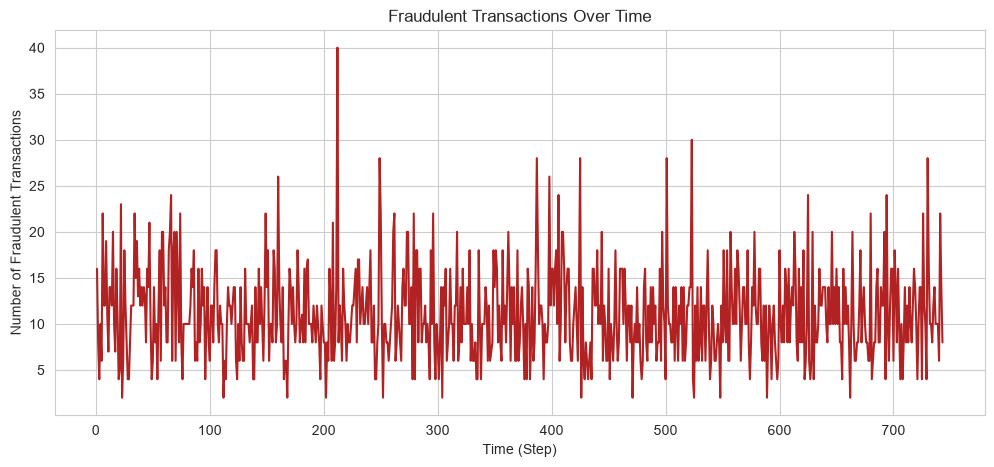

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    fraud_over_time.index,
    fraud_over_time.values,
    linewidth=1.5,
    color="firebrick"
)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Time (Step)")
plt.ylabel("Number of Fraudulent Transactions")

plt.grid(True)

plt.savefig(
    "../images/9. fraud_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

A line chart is appropriate because the step variable represents continuous time. It helps reveal whether fraud activity follows a trend or occurs at fairly consistent levels throughout the observation period.

### Findings

Fraudulent transactions occur throughout the entire observation period rather than being concentrated within a few specific hours.

While several temporary spikes in fraudulent activity are observed, the overall pattern remains relatively stable with no sustained upward or downward trend. These spikes indicate short periods of increased fraud but do not suggest a long-term change in fraud frequency.

Overall, the results show that fraudulent activity is continuous and can occur at any point during the observation period.

### Business Insight

Since fraudulent transactions occur throughout the observation period, fraud detection systems should operate continuously rather than focusing on specific hours. The occasional spikes in activity also suggest that monitoring systems should be capable of responding quickly to sudden increases in suspicious transactions.

# Conclusion

This exploratory data analysis identified several important characteristics of fraudulent transactions within the financial dataset.

Fraud is extremely rare, accounting for only a very small proportion of all transactions, which highlights the highly imbalanced nature of the data. Fraudulent activity occurs exclusively in TRANSFER and CASH_OUT transactions, with TRANSFER exhibiting the highest fraud rate.

Compared with legitimate transactions, fraudulent transactions generally involve larger transaction amounts and originate from accounts with substantially higher sender balances. Recipient account balances also differ noticeably, with many fraudulent transfers involving destination accounts that initially contain little or no recorded balance.

Although fraudulent transactions occur throughout the observation period, they do not follow a clear increasing or decreasing trend, indicating that fraud can happen at any time.

Overall, these findings suggest that transaction type, transaction amount, sender and recipient account balances, and balance behaviour are valuable indicators for distinguishing fraudulent transactions from legitimate ones. These insights provide a strong foundation for developing machine learning models capable of detecting financial fraud.

# Key Findings

- Fraud accounts for only about 0.13% of all transactions, indicating severe class imbalance.
- Fraud occurs only in TRANSFER and CASH_OUT transactions.
- TRANSFER transactions have the highest fraud rate.
- Fraudulent transactions generally involve much larger transaction amounts.
- Fraudulent transactions often originate from accounts with higher sender balances.
- Recipient accounts involved in fraud frequently have very low or zero initial balances.
- Fraud occurs throughout the observation period with occasional spikes but no consistent time trend.
- Multiple transaction characteristics should be considered together when building fraud detection models, as no single feature perfectly identifies fraudulent activity.

# Business Recommendations

Based on the findings from this analysis, the following recommendations are suggested:

- Prioritize monitoring of **TRANSFER** and **CASH_OUT** transactions, as they account for all fraudulent activities in the dataset.
- Apply additional verification procedures to high-value transactions before they are completed.
- Monitor transactions involving unusual sender and recipient account balance patterns.
- Implement continuous fraud monitoring, since fraudulent transactions occur throughout the observation period rather than during specific hours.
- Combine multiple transaction characteristics, such as transaction type, amount, and account balances, when developing fraud detection models instead of relying on a single feature.